In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

R = 1
C = 1
V_source = 5


# Define the PINN model
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 50),   # Input layer with 1 feature
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 1)    # Output layer for v(t)
        )

    def forward(self, t):
        return self.net(t)

# Define the Poisson equation loss function
def capacitor_charge_loss(model, t):
    v = model(t)
    v_t = torch.autograd.grad(v, t, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    f = (v_t + v/(R*C) - V_source/(R*C))**2  # Poisson equation: u_xx = 1
    t_0 = torch.tensor([0.0], requires_grad=True)
    v_0 = model(t_0)
    initial_conditions = (v_0 - 0)**2
    return torch.mean(f) + torch.mean(initial_conditions)

# Training data
t = 10*torch.rand(100, 1)  # Randomly sampled points in [0, 1]
t.requires_grad = True

# Create PINN model
model = PINN()

optimizer = optim.Adam(params=[{'params': model.parameters()}, {'params': t}], lr=0.001)

# Training loop
epochs = 10000
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Compute the loss
    loss = capacitor_charge_loss(model, t)
    
    # Backpropagation
    loss.backward()
    optimizer.step()
    
    if epoch % 1000 == 0:
        print(f"Epoch [{epoch}/{epochs}], Loss: {loss.item()}")


Epoch [0/10000], Loss: 34.170753479003906
Epoch [1000/10000], Loss: 0.0009395643719471991
Epoch [2000/10000], Loss: 0.00012699294893536717
Epoch [3000/10000], Loss: 1.932879604282789e-05
Epoch [4000/10000], Loss: 8.393052667088341e-06
Epoch [5000/10000], Loss: 5.542518010770436e-06
Epoch [6000/10000], Loss: 3.834888048004359e-06
Epoch [7000/10000], Loss: 2.5026574803632684e-06
Epoch [8000/10000], Loss: 1.4714681810801267e-06
Epoch [9000/10000], Loss: 8.150119015226664e-07


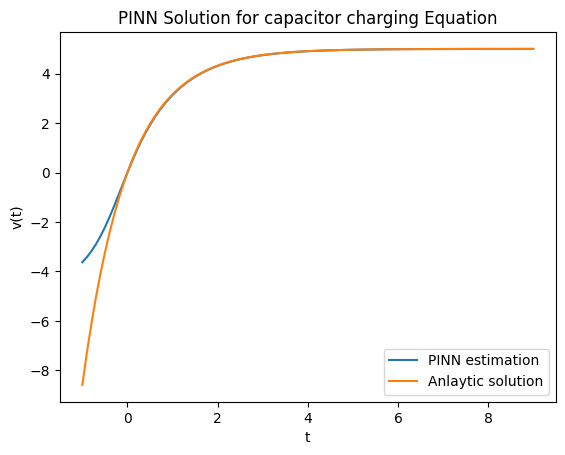

In [14]:
# Test the model
t_test = 10*(torch.linspace(0, 1, 100).reshape(-1, 1)-.1)
v_test = model(t_test)
v_real = V_source*(1-torch.exp(-t_test/(R*C)))

# Plot the results
import matplotlib.pyplot as plt
plt.plot(t_test.detach().numpy(), v_test.detach().numpy(), label="PINN estimation")
plt.plot(t_test.detach().numpy(), v_real.detach().numpy(), label="Anlaytic solution")
plt.xlabel('t')
plt.ylabel('v(t)')
plt.title('PINN Solution for capacitor charging Equation')
plt.legend()
plt.show()